# Baseline Supervised Modelling

## Objective

The objective of this notebook is to establish supervised baseline performance on the engineered feature set and assess the extent to which known fraud patterns can be captured using labelled data.

These baseline models serve as reference points for later comparison with anomaly detection methods, which are better suited to identifying previously unseen or behaviourally unusual fraud patterns.

Given the severe class imbalance of the dataset, the analysis focuses on evaluation metrics appropriate for rare-event detection rather than overall accuracy.

In [13]:
# =============================================================
# Imports
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap

# =============================================================
# Configuration
# =============================================================
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.6f}".format)

## Data Loading

The model baseline uses the processed feature-engineered dataset generated in the previous notebook. This ensures separation between feature construction and model development, improving reproducibility and modularity.

In [14]:
# -------------------------------------------------------------
# Load processed feature-engineered dataset
# -------------------------------------------------------------
df = pd.read_csv("../data/processed/feature_engineered.csv")

# Quick inspection
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,log_amount,balance_error,abs_balance_error,log_balance_error,dest_balance_change,log_amount_balance_error,log_amount_to_balance_ratio,isFraud
0,-1.703042,-0.281560,-0.229810,-0.237622,-0.323814,-0.333411,-0.907462,0.331480,-0.331480,-0.331480,-0.152896,-1.862368,-0.807934,0
1,-1.703042,-0.294767,-0.281359,-0.285812,-0.323814,-0.333411,-1.824023,0.331480,-0.331480,-0.331480,-0.152896,-1.862368,-0.805425,0
2,-1.703042,-0.297555,-0.288654,-0.292442,-0.323814,-0.333411,-3.106552,0.331480,-0.331480,-0.331480,-0.152896,-1.862368,-0.750610,1
3,-1.703042,-0.297555,-0.288654,-0.292442,-0.317582,-0.333411,-3.106552,0.331480,-0.331480,-0.331480,-0.178952,-1.862368,-0.750610,1
4,-1.703042,-0.278532,-0.274329,-0.282221,-0.323814,-0.333411,-0.813537,0.331480,-0.331480,-0.331480,-0.152896,-1.862368,-0.790720,0


## Dataset Overview

The dataset consists of engineered behavioural features derived from transaction-level data. These features capture transaction magnitude, balance consistency, and structural transaction dynamics.

The target variable is:

- `isFraud`: binary indicator where 1 represents fraudulent transactions and 0 represents legitimate transactions

Before modelling, the dataset structure and class distribution are verified.

In [15]:
# =============================================================
# Dataset overview
# =============================================================
print("Shape:", df.shape)

print("\nClass distribution:")
print(df["isFraud"].value_counts())

print("\nClass proportions:")
print(df["isFraud"].value_counts(normalize=True))

Shape: (6362620, 14)

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Class proportions:
isFraud
0   0.998709
1   0.001291
Name: proportion, dtype: float64


## Problem Definition and Evaluation Strategy

Fraud detection in this dataset is formulated as a binary classification problem, where:

- 0 represents legitimate transactions
- 1 represents fraudulent transactions

However, the modelling challenge extends beyond standard classification. Fraudulent transactions represent only a very small proportion of all observations, resulting in a highly imbalanced learning problem.

This imbalance makes accuracy a misleading metric, since a model that predicts every transaction as legitimate would still achieve very high accuracy while being operationally useless.

Therefore, evaluation focuses on:

- **Precision**: proportion of predicted fraud cases that are actually fraud
- **Recall**: proportion of true fraud cases that are correctly identified
- **F1-score**: harmonic mean of precision and recall
- **ROC-AUC**: ranking performance across thresholds
- **PR-AUC**: especially informative in highly imbalanced fraud settings

This evaluation framework aligns the analysis with the practical requirements of rare-event fraud detection.

## Feature-Target Split

The target variable is separated from the predictor space.

The feature `isFlaggedFraud` is excluded from modelling because it represents a rule-based fraud flag and may introduce leakage by providing information too close to the target label.

In [16]:
# =============================================================
# Separate predictors and target
# =============================================================
y = df["isFraud"]

columns_to_drop = ["isFraud"]
if "isFlaggedFraud" in df.columns:
    columns_to_drop.append("isFlaggedFraud")

X = df.drop(columns=columns_to_drop)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFraud rate: {:.4%}".format(y.mean()))

Feature matrix shape: (6362620, 13)
Target shape: (6362620,)

Fraud rate: 0.1291%


## Train-Test Split

The dataset is split into training and test sets using stratified sampling to preserve the original fraud distribution in both subsets.

This is essential in highly imbalanced problems, where random splitting can distort the class distribution and bias model evaluation.

In [17]:
# =============================================================
# Stratified train-test split
# =============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training fraud rate: {:.4%}".format(y_train.mean()))
print("Test fraud rate: {:.4%}".format(y_test.mean()))

Training fraud rate: 0.1291%
Test fraud rate: 0.1291%


## Evaluation Helper

To ensure consistency across models, a common evaluation function is defined. This function reports the main fraud detection metrics and returns them in a structured format for later comparison.

In [18]:
# =============================================================
# Evaluation helper
# =============================================================
def evaluate_classifier(model, X_train, X_test, y_train, y_test, threshold=0.5):
    """
    Train and evaluate a binary classifier for fraud detection.

    Parameters
    ----------
    model : estimator
        Scikit-learn compatible classifier implementing fit(), predict(),
        and predict_proba().
    X_train : pandas.DataFrame
        Training feature matrix.
    X_test : pandas.DataFrame
        Test feature matrix.
    y_train : pandas.Series
        Training labels.
    y_test : pandas.Series
        Test labels.
    threshold : float, optional
        Probability threshold used to generate class predictions.

    Returns
    -------
    dict
        Dictionary containing predictions, probabilities, and evaluation metrics.
    """
    # ---------------------------------------------------------
    # Train model
    # ---------------------------------------------------------
    model.fit(X_train, y_train)

    # ---------------------------------------------------------
    # Generate predictions and probabilities
    # ---------------------------------------------------------
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # ---------------------------------------------------------
    # Compute evaluation metrics
    # ---------------------------------------------------------
    results = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    # ---------------------------------------------------------
    # Print summary
    # ---------------------------------------------------------
    print(f"ROC-AUC: {results['roc_auc']:.4f}")
    print(f"PR-AUC : {results['pr_auc']:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return results

## Baseline 0: Dummy Classifier

A dummy classifier provides a trivial benchmark. This ensures that subsequent models are compared against a meaningful reference rather than against class imbalance alone.

In [19]:
# =============================================================
# Dummy classifier baseline
# =============================================================
dummy_model = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)

dummy_results = evaluate_classifier(
    model=dummy_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

ROC-AUC: 0.4996
PR-AUC : 0.0013

Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987   1270881
           1     0.0006    0.0006    0.0006      1643

    accuracy                         0.9974   1272524
   macro avg     0.4997    0.4996    0.4996   1272524
weighted avg     0.9974    0.9974    0.9974   1272524

Confusion Matrix:
[[1269198    1683]
 [   1642       1]]


## Baseline 1: Logistic Regression

Logistic Regression is used as an interpretable linear baseline. Although fraud behaviour is likely to depend on non-linear interactions, this model helps determine whether the engineered feature set already contains linearly exploitable signal.

Class imbalance is handled using class weighting.

In [20]:
# =============================================================
# Logistic Regression baseline
# =============================================================
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_reg_results = evaluate_classifier(
    model=log_reg,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

ROC-AUC: 0.9905
PR-AUC : 0.6392

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9465    0.9725   1270881
           1     0.0225    0.9550    0.0441      1643

    accuracy                         0.9465   1272524
   macro avg     0.5112    0.9507    0.5083   1272524
weighted avg     0.9987    0.9465    0.9713   1272524

Confusion Matrix:
[[1202870   68011]
 [     74    1569]]


## Baseline 2: Random Forest

Random Forest is used as a non-linear ensemble baseline capable of capturing interactions between variables. This is particularly relevant given the behavioural patterns identified during exploratory analysis.

In [21]:
# =============================================================
# Random Forest baseline
# =============================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results = evaluate_classifier(
    model=rf_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

ROC-AUC: 0.9986
PR-AUC : 0.9976

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

Confusion Matrix:
[[1270881       0]
 [      4    1639]]


## Baseline 3: XGBoost

XGBoost is included as the state-of-the-art supervised baseline for structured tabular fraud detection. Its ability to model non-linear relationships, feature interactions, and imbalanced data makes it especially suitable for this problem.

In [22]:
# =============================================================
# XGBoost baseline
# =============================================================
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_results = evaluate_classifier(
    model=xgb_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

ROC-AUC: 0.9995
PR-AUC : 0.9892

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    1.0000    0.9999   1270881
           1     0.9675    0.9251    0.9459      1643

    accuracy                         0.9999   1272524
   macro avg     0.9837    0.9625    0.9729   1272524
weighted avg     0.9999    0.9999    0.9999   1272524

Confusion Matrix:
[[1270830      51]
 [    123    1520]]


## Model Comparison

The following table summarizes baseline performance across all supervised models. PR-AUC is particularly important given the severe class imbalance.

In [23]:
# =============================================================
# Comparison table
# =============================================================
comparison = pd.DataFrame([
    {
        "Model": "Dummy Classifier",
        "Precision": dummy_results["precision"],
        "Recall": dummy_results["recall"],
        "F1": dummy_results["f1"],
        "ROC-AUC": dummy_results["roc_auc"],
        "PR-AUC": dummy_results["pr_auc"]
    },
    {
        "Model": "Logistic Regression",
        "Precision": log_reg_results["precision"],
        "Recall": log_reg_results["recall"],
        "F1": log_reg_results["f1"],
        "ROC-AUC": log_reg_results["roc_auc"],
        "PR-AUC": log_reg_results["pr_auc"]
    },
    {
        "Model": "Random Forest",
        "Precision": rf_results["precision"],
        "Recall": rf_results["recall"],
        "F1": rf_results["f1"],
        "ROC-AUC": rf_results["roc_auc"],
        "PR-AUC": rf_results["pr_auc"]
    },
    {
        "Model": "XGBoost",
        "Precision": xgb_results["precision"],
        "Recall": xgb_results["recall"],
        "F1": xgb_results["f1"],
        "ROC-AUC": xgb_results["roc_auc"],
        "PR-AUC": xgb_results["pr_auc"]
    }
])

comparison = comparison.sort_values(by="PR-AUC", ascending=False)
comparison

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Random Forest,1.000000,0.997565,0.998781,0.998559,0.997569
3,XGBoost,0.967537,0.925137,0.945862,0.999495,0.989193
1,Logistic Regression,0.022550,0.954960,0.044059,0.990460,0.639233
0,Dummy Classifier,0.000594,0.000609,0.000601,0.499642,0.001291


## Precision-Recall Curves

Precision-Recall curves are particularly informative in rare-event fraud detection because they focus on minority-class performance and the trade-off between missed fraud and false positives.

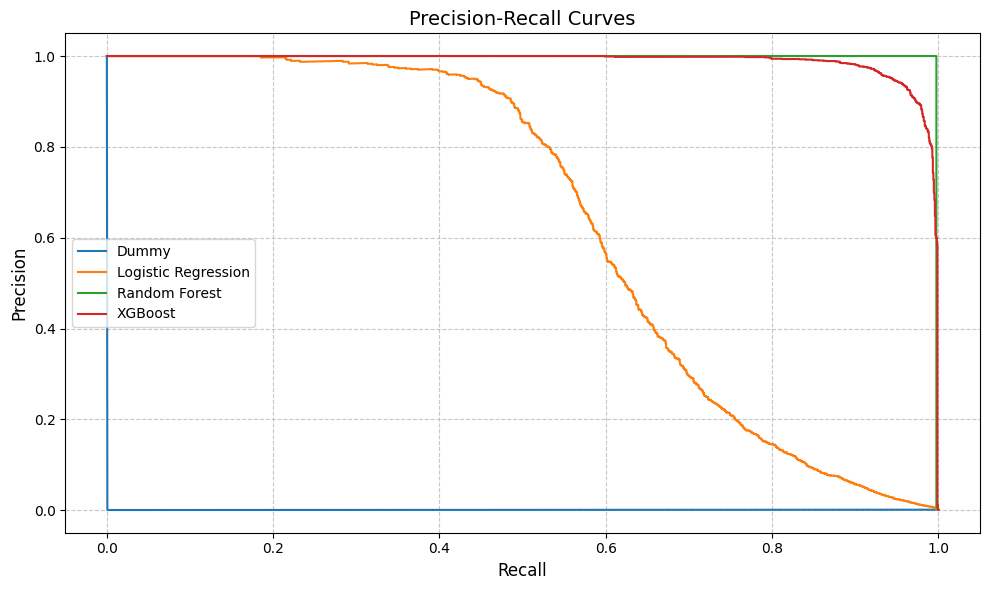

In [24]:
# =============================================================
# Precision-Recall curves
# =============================================================
plt.figure(figsize=(10, 6))

for label, results in [
    ("Dummy", dummy_results),
    ("Logistic Regression", log_reg_results),
    ("Random Forest", rf_results),
    ("XGBoost", xgb_results)
]:
    precision, recall, _ = precision_recall_curve(y_test, results["y_prob"])
    plt.plot(recall, precision, label=label)

plt.title("Precision-Recall Curves", fontsize=14)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## ROC Curves

ROC curves are reported as an additional ranking-based evaluation tool. However, under severe class imbalance, they should be interpreted together with PR-AUC rather than in isolation.

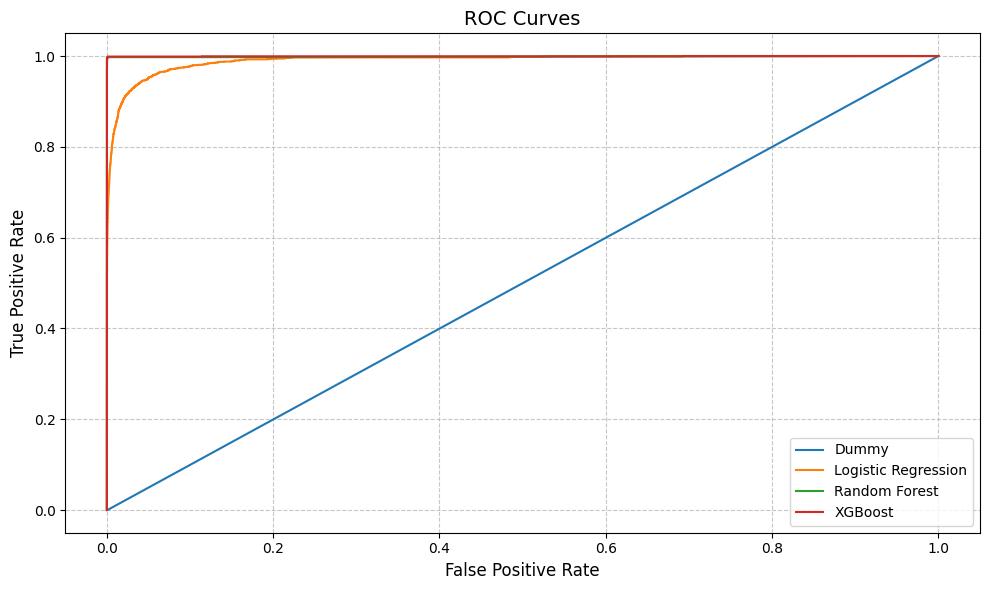

In [25]:
# =============================================================
# ROC curves
# =============================================================
plt.figure(figsize=(10, 6))

for label, results in [
    ("Dummy", dummy_results),
    ("Logistic Regression", log_reg_results),
    ("Random Forest", rf_results),
    ("XGBoost", xgb_results)
]:
    fpr, tpr, _ = roc_curve(y_test, results["y_prob"])
    plt.plot(fpr, tpr, label=label)

plt.title("ROC Curves", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Model Interpretability (Explainable AI)

To improve transparency and support financial risk analysis, SHAP (SHapley Additive exPlanations) is used to interpret the XGBoost model.

SHAP is particularly suitable for this project because it provides:

- **Global explanations**: which features are most influential overall
- **Local explanations**: why a specific transaction is assigned a high fraud probability

This is especially important in financial contexts, where explainability supports model validation, auditability, and justifiable decision-making.

100%|===================| 1272499/1272524 [129:22<00:00]        

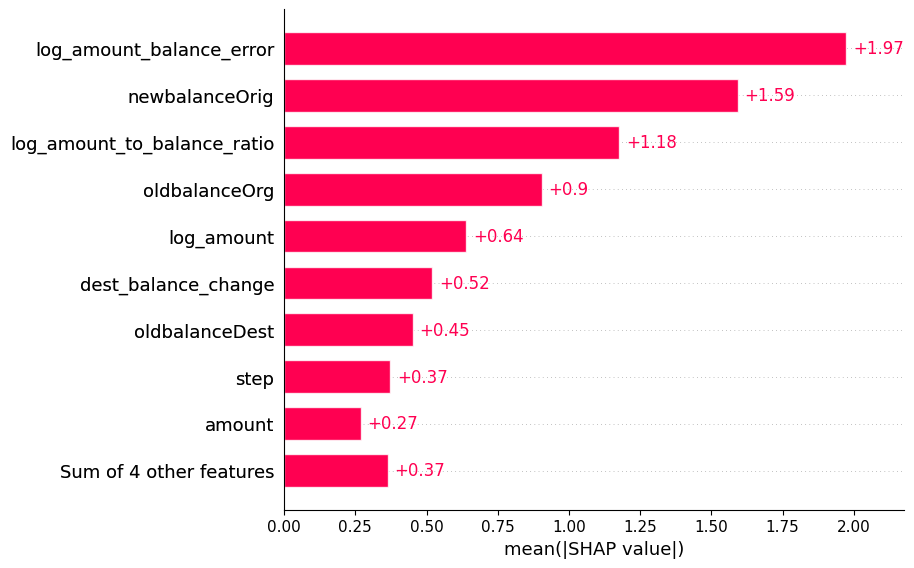

In [26]:
# =============================================================
# SHAP explainer for XGBoost
# =============================================================
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# =============================================================
# Global SHAP importance
# =============================================================
shap.plots.bar(shap_values, max_display=10)

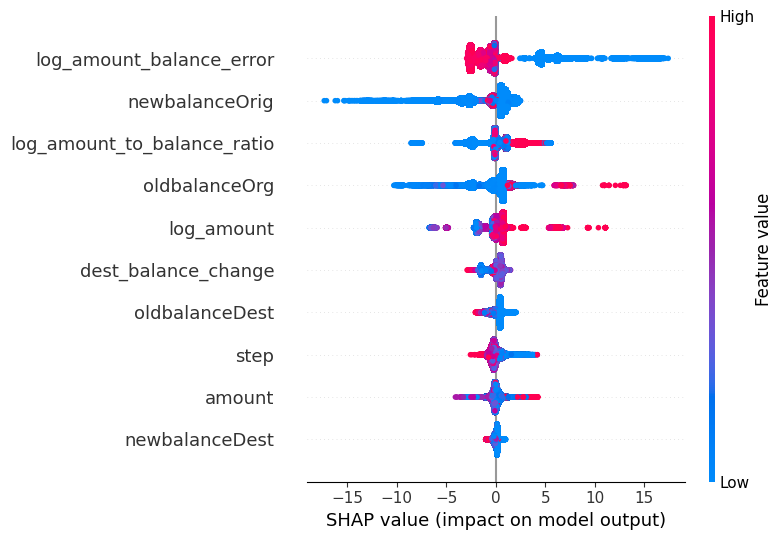

In [27]:
# =============================================================
# SHAP summary plot
# =============================================================
shap.summary_plot(shap_values.values, X_test, max_display=10)

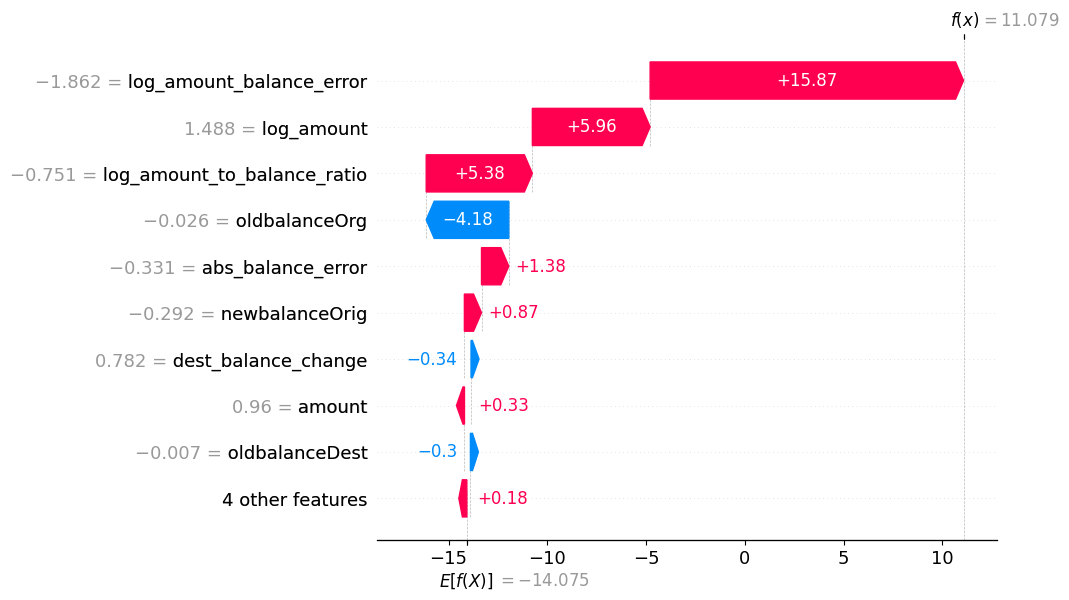

In [28]:
# =============================================================
# Local explanation for one fraudulent transaction
# =============================================================
fraud_indices = y_test[y_test == 1].index

# Select the first fraud case from the test set
fraud_idx = fraud_indices[0]

# Find its positional index inside X_test
fraud_pos = X_test.index.get_loc(fraud_idx)

# Waterfall plot for local explanation
shap.plots.waterfall(shap_values[fraud_pos], max_display=10)

## Interpretation of Baseline Results

The baseline modelling stage evaluates the extent to which engineered behavioural features can separate fraudulent from legitimate activity under supervised learning.

The comparison between Logistic Regression, Random Forest, and XGBoost provides insight into whether fraud can be captured through linear structure, non-linear interactions, or more advanced boosting-based representations.

Given the state of the art in tabular fraud detection, strong XGBoost performance would confirm that the engineered features contain meaningful discriminative structure. However, even strong supervised results do not eliminate the need for anomaly detection, since supervised models remain limited to fraud patterns that are already represented in the labelled data.

## Optional Robustness Check

A useful extension of this baseline would be an ablation experiment in which the strongest balance-related features are removed and the models are retrained.

This would help quantify the extent to which the baseline models rely on deterministic synthetic balance patterns rather than on broader behavioural generalization.

## Conclusions

The baseline modelling stage confirms that the engineered features contain meaningful predictive signal for fraud detection.

Key observations include:

- Simple baselines are insufficient under severe class imbalance
- Behaviourally engineered features improve discriminative performance
- Non-linear models are expected to outperform linear baselines due to feature interactions
- Performance limitations under class imbalance justify the exploration of anomaly detection methods

These findings establish a reference benchmark for the next stage of the project, where anomaly detection techniques will be evaluated.